In [13]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patheffects as pe
from scipy.integrate import solve_ivp
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": False,       # keep your sizes stable
    "mathtext.fontset": "cm",   # Computer Modern for math only
    # keep your normal font choice as-is (optional)
    # "font.family": "sans-serif",
    # "font.sans-serif": ["DejaVu Sans"],
})

## Fig 1. No feedback baseline (fixed game)

### Baseline game with no environmental feedback

$$M = \begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
$$

\begin{eqnarray}
\dot{x} = x(1-x)(-(\alpha+\beta)x+\alpha)
\end{eqnarray}

#### Panel A. Stability diagram in the payoff-parameter space ($\alpha, \beta$)

In [2]:
# phase diagram
def classify(alpha, beta):
    """Output:
       0 -> strategy 1 dominates (x=0 stable)
       1 -> strategy 2 dominates (x=1 stable)
       2 -> coexistence (interior stable)
       3 -> coordination/bistability (0 and 1 stable)
      -1 -> on axes (alpha=0 or beta=0)
    """
    if alpha < 0 and beta > 0:
        return 0
    if alpha > 0 and beta < 0:
        return 1
    if alpha > 0 and beta > 0:
        return 2
    if alpha < 0 and beta < 0:
        return 3
    return -1

A = np.linspace(-1, 1, 201)
B = np.linspace(-1, 1, 201)
AA, BB = np.meshgrid(A, B)
Z = np.zeros_like(AA, dtype=float)
for i in range(AA.shape[0]):
    for j in range(AA.shape[1]):
        Z[i, j] = classify(AA[i, j], BB[i, j])

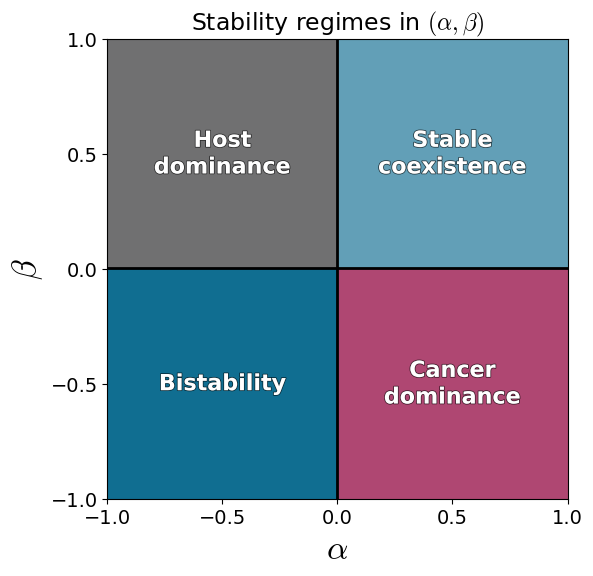

In [40]:
COL_HOST    = "#707071"   # host dominance
COL_COEX    = "#629FB7"   # stable coexistence
COL_BISTAB  = "#106E91"   # bistability
COL_CANCER  = "#AF4772"   # cancer dominance

# 0 host dom, 1 cancer dom, 2 coexist, 3 bistability
cmap = ListedColormap([COL_HOST, COL_CANCER, COL_COEX, COL_BISTAB])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

Z_masked = Z.astype(float)
Z_masked[Z_masked < 0] = np.nan  # hide alpha=0 or beta=0 cells

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(
    Z_masked,
    origin="lower",
    extent=[A.min(), A.max(), B.min(), B.max()],
    aspect="equal",
    cmap=cmap,
    norm=norm,
    interpolation="nearest"
)

ax.axhline(0.001, linewidth=2, color='black')
ax.axvline(0, linewidth=2, color='black')
ax.set(xticks=np.arange(-1, 1.1, 0.5),
       yticks=np.arange(-1, 1.1, 0.5)
      )
ax.set_title(r'Stability regimes in $(\alpha,\beta)$',fontsize=17)
ax.set_xlabel(r'$\alpha$', fontsize=24)
ax.set_ylabel(r'$\beta$', fontsize=24)
ax.tick_params(axis='both', labelsize=14)

# text
txt_kw = dict(
    fontsize=16, color="white", ha="center", va="center", fontweight="semibold",
    path_effects=[pe.withStroke(linewidth=1.2, foreground=(0,0,0,0.6))]
)

ax.text(-0.5,  0.5, "Host\ndominance", **txt_kw)
ax.text( 0.5,  0.5, "Stable\ncoexistence", **txt_kw)
ax.text(-0.5, -0.5, "Bistability", **txt_kw)
ax.text( 0.5, -0.5, "Cancer\ndominance", **txt_kw)

plt.tight_layout()
plt.savefig('Figures/fig1A_phase_alpha_beta.png', dpi=600, bbox_inches="tight")
plt.savefig('Figures/fig1A_phase_alpha_beta.svg', bbox_inches="tight")
plt.show()

#### Panel B. $x(t)$ trajectories

In [27]:
def rhs(t, x, alpha, beta):
    x = x[0]
    dx = x*(1-x)*(alpha - (alpha+beta)*x)
    return [dx]

def simulate(alpha, beta, x0, tmax=60, npts=800):
    t_eval = np.linspace(0, tmax, npts)
    sol = solve_ivp(rhs, (0, tmax), [x0], t_eval=t_eval,
                    args=(alpha, beta), rtol=1e-8, atol=1e-10)
    return sol.t, sol.y[0]

def x_star(alpha, beta):
    if alpha*beta > 0 and (alpha+beta) != 0:
        xs = alpha/(alpha+beta)
        if 0 < xs < 1:
            return xs
    return None

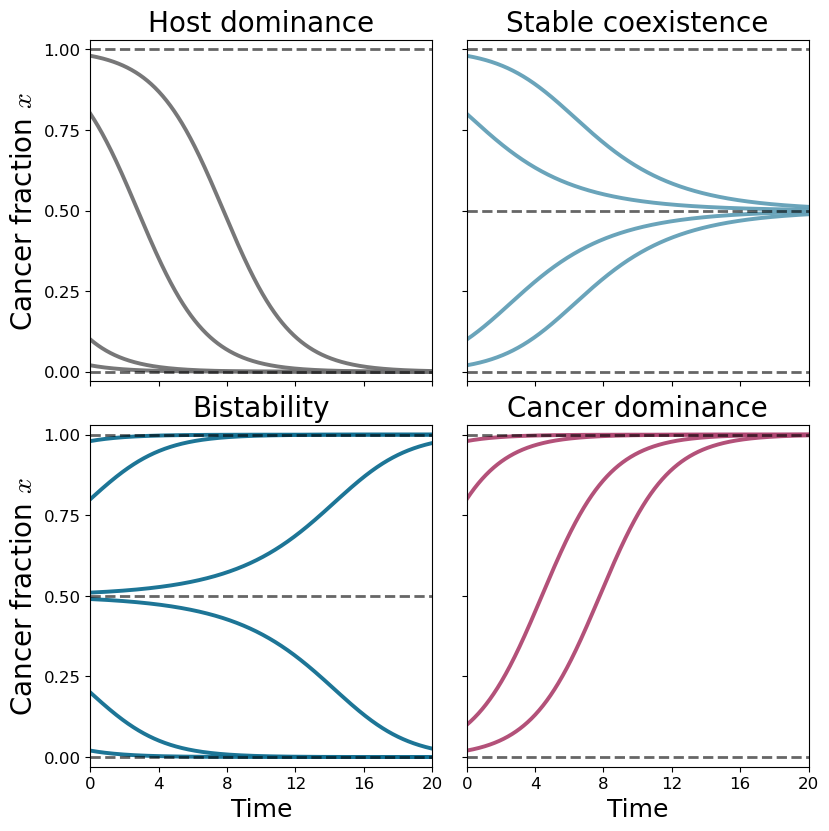

In [44]:
COL = {
    "host":    "#707071",
    "coexist": "#629FB7",
    "bistab":  "#106E91",
    "cancer":  "#AF4772",
}

# Representative parameters (one per quadrant)
cases = [
    ("Host dominance",      -0.5, +0.5, COL["host"]),
    ("Stable coexistence",  +0.5, +0.5, COL["coexist"]),
    ("Bistability",         -0.5, -0.5, COL["bistab"]),
    ("Cancer dominance",    +0.5, -0.5, COL["cancer"]),
]
# Initial conditions (several to show convergence)
x0s_general = [0.02, 0.10, 0.80, 0.98]
# show both basins + "just below/above" the unstable point (~0.5 here)
x0s_bistab  = [0.02, 0.20, 0.49, 0.51, 0.80, 0.98]

# Make Panel B square overall, so each small panel can be square and still large
fig, axs = plt.subplots(2, 2, figsize=(8.2, 8.2), sharex=True, sharey=True, constrained_layout=True)
axs = axs.ravel()

for ax, (name, a, b, color) in zip(axs, cases):
    x0s = x0s_bistab if "Bistability" in name else x0s_general

    for x0 in x0s:
        t, x = simulate(a, b, x0, tmax=20)
        ax.plot(t, x, lw=2.8, color=color, alpha=0.95)

    # equilibrium guides (keep subtle)
    ax.axhline(0, ls="--", lw=2, color="black", alpha=0.6)
    ax.axhline(1, ls="--", lw=2, color="black", alpha=0.6)
    xs = x_star(a, b)
    if xs is not None:
        ax.axhline(xs, ls="--", lw=2, color="black", alpha=0.6)

    ax.set_title(name, fontsize=20, pad=6)
    ax.set_xlim(0, 20)
    ax.set_ylim(-0.03, 1.03)

    # square subplot boxes
    ax.set_box_aspect(1)

    # integer-ish ticks on time, clean y ticks
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.tick_params(labelsize=12)

# axis labels (outer only)
axs[2].set_xlabel("Time", fontsize=18)
axs[3].set_xlabel("Time", fontsize=18)
axs[0].set_ylabel(r"Cancer fraction $x$", fontsize=20)
axs[2].set_ylabel(r"Cancer fraction $x$", fontsize=20)

plt.savefig("Figures/fig1B_trajectories.svg", bbox_inches="tight")
plt.savefig("Figures/fig1B_trajectories.png", dpi=600, bbox_inches="tight")

plt.show()
